In [1]:
import pandas as pd

In [2]:
train_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\train"
test_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\test"

Loading training dataset...
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Class mapping: {'acai': 0, 'cupuacu': 1, 'graviola': 2, 'guarana': 3, 'pupunha': 4, 'tucuma': 5}

Training samples loaded: 90

Loading testing dataset...
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Class mapping: {'acai': 0, 'cupuacu': 1, 'graviola': 2, 'guarana': 3, 'pupunha': 4, 'tucuma': 5}

Testing samples loaded: 30

Training set: (90, 128, 128, 3), Labels: (90, 6)
Testing set: (30, 128, 128, 3), Labels: (30, 6)
Number of classes: 6



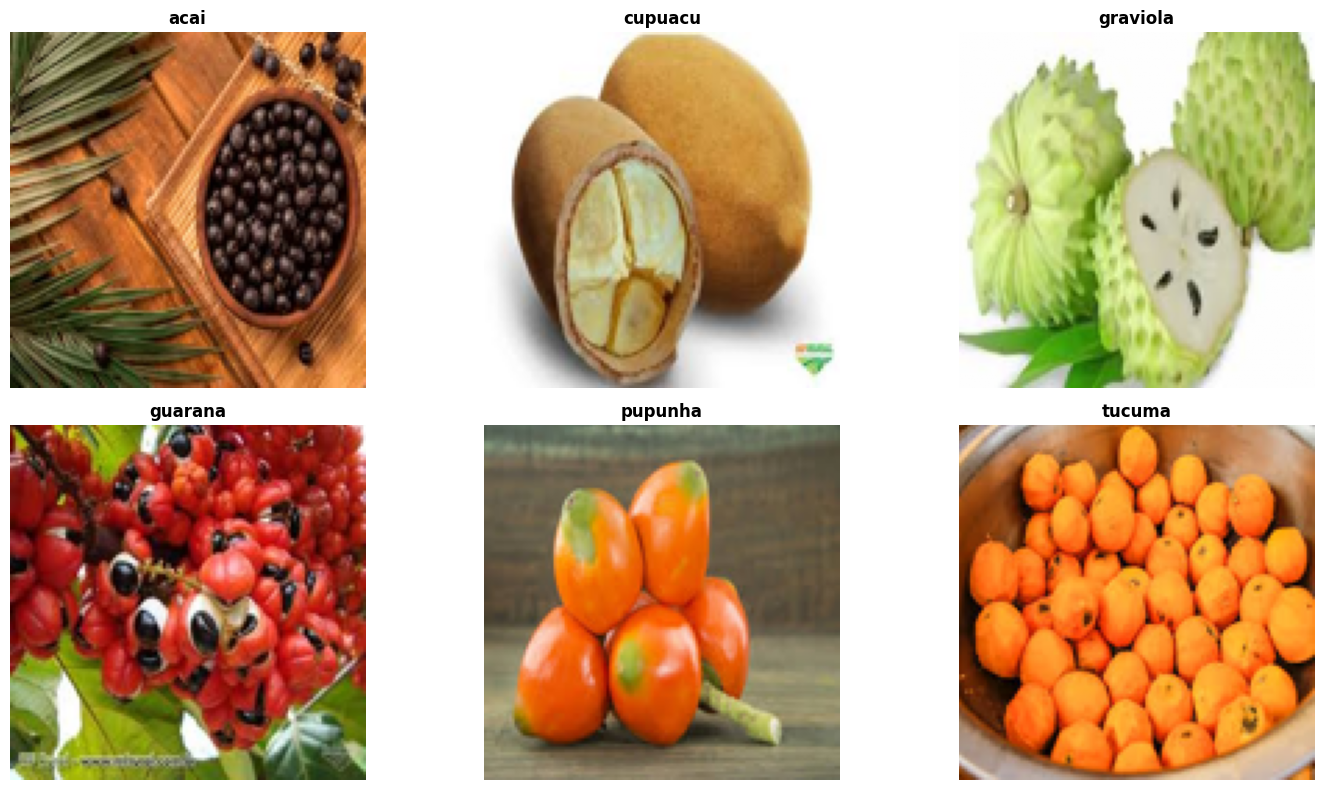

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

img_height, img_width = 128, 128  # Adjust size for fruit images
train_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\train"
test_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\test"

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted class names (acai, cupuacu, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels
    
    print(f"Classes found: {class_names}")
    print(f"Class mapping: {class_map}\n")
    
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        
        if not os.path.isdir(class_path):
            continue
            
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            
            try:
                # Load image using PIL
                img = Image.open(img_path).convert("RGB")  # Convert to RGB for color images
                img = img.resize((img_width, img_height))  # Resize to (128, 128)
                img = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
    
    return np.array(images), np.array(labels), class_names

# Load training and testing datasets
print("Loading training dataset...")
x_train, y_train, class_names = load_images_from_folder(train_dir)
print(f"Training samples loaded: {len(x_train)}\n")

print("Loading testing dataset...")
x_test, y_test, _ = load_images_from_folder(test_dir)
print(f"Testing samples loaded: {len(x_test)}\n")

# Reshape images for Keras input (already in correct shape, but confirming)
x_train = x_train.reshape(-1, img_height, img_width, 3)  # Shape (num_samples, 128, 128, 3)
x_test = x_test.reshape(-1, img_height, img_width, 3)

# One-hot encode labels
num_classes = len(class_names)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
print(f"Number of classes: {num_classes}\n")

# Visualize one image from each fruit class
plt.figure(figsize=(15, 8))

# Find one image from each class
class_indices = {}
for i, label in enumerate(y_train):
    label_idx = np.argmax(label)
    if label_idx not in class_indices:
        class_indices[label_idx] = i

# Display one image per class
num_cols = 3
num_rows = (num_classes + num_cols - 1) // num_cols

for idx, (label_idx, sample_idx) in enumerate(sorted(class_indices.items())):
    plt.subplot(num_rows, num_cols, idx + 1)
    plt.imshow(x_train[sample_idx])  # Display RGB image directly
    plt.title(f"{class_names[label_idx]}", fontsize=12, fontweight='bold')
    plt.axis("off")

plt.tight_layout()
plt.show()

### What did you Observe?

I observed there are 6 category of image, that is acai, cupuacu, graviola, guarana, pupunha and tucuma

In [14]:
import os
from PIL import Image

def check_and_remove_corrupted_images(train_dir):
    """
    Check for corrupted images in the dataset and remove them.
    
    Parameters:
    train_dir (str): Path to the train directory containing class subdirectories
    """
    
    corrupted_images = []
    total_images = 0
    valid_images = 0
    
    # Get all class directories
    class_directories = sorted([d for d in os.listdir(train_dir) 
                               if os.path.isdir(os.path.join(train_dir, d))])
    
    print(f"Scanning {len(class_directories)} classes for corrupted images...\n")
    print("=" * 70)
    
    # Iterate through each class subdirectory
    for class_name in class_directories:
        class_path = os.path.join(train_dir, class_name)
        print(f"\nChecking class: {class_name}")
        print("-" * 70)
        
        # Get all files in the class directory
        files = os.listdir(class_path)
        
        for filename in files:
            file_path = os.path.join(class_path, filename)
            
            # Skip if it's a directory
            if os.path.isdir(file_path):
                continue
            
            total_images += 1
            
            try:
                # Attempt to open and validate the image
                img = Image.open(file_path)
                img.verify()  # Verify the image is valid
                valid_images += 1
                
            except (IOError, OSError, Image.UnidentifiedImageError, SyntaxError) as e:
                # Image is corrupted
                corrupted_images.append(file_path)
                print(f"Removed corrupted image: {file_path}")
                
                try:
                    # Remove the corrupted image from the directory
                    os.remove(file_path)
                    print(f"  ✗ Successfully deleted from disk\n")
                except Exception as delete_error:
                    print(f"  ✗ Error deleting file: {delete_error}\n")
            
            except Exception as e:
                # Other unexpected errors
                print(f"  ✗ Unexpected error for {file_path}: {e}\n")
    
    # Print summary
    print("\n" + "=" * 70)
    print("SUMMARY REPORT")
    print("=" * 70)
    print(f"Total images scanned: {total_images}")
    print(f"Valid images: {valid_images}")
    print(f"Corrupted images found: {len(corrupted_images)}")
    print("=" * 70)
    
    # Final message
    if len(corrupted_images) == 0:
        print("\n✓ No Corrupted Images Found.")
    else:
        print(f"\n✗ Found and removed {len(corrupted_images)} corrupted image(s):")
        for img_path in corrupted_images:
            print(f"  - {img_path}")
    
    print("=" * 70 + "\n")
    
    return corrupted_images


# Main execution
if __name__ == "__main__":
    train_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\train"
    
    if os.path.exists(train_dir):
        print("\n")
        check_and_remove_corrupted_images(train_dir)
    else:
        print(f"Error: The path '{train_dir}' does not exist.")
        print("Please provide a valid path to the train directory.")



Scanning 6 classes for corrupted images...


Checking class: acai
----------------------------------------------------------------------

Checking class: cupuacu
----------------------------------------------------------------------

Checking class: graviola
----------------------------------------------------------------------

Checking class: guarana
----------------------------------------------------------------------

Checking class: pupunha
----------------------------------------------------------------------

Checking class: tucuma
----------------------------------------------------------------------

SUMMARY REPORT
Total images scanned: 90
Valid images: 90
Corrupted images found: 0

✓ No Corrupted Images Found.



## Task 2: Loading and Preprocessing Image Data in keras:

Loading training dataset...
----------------------------------------------------------------------
Found 90 files belonging to 6 classes.
Using 72 files for training.
Training dataset created successfully!
Train dataset batches: 3
Batch size: 32

Loading validation dataset...
----------------------------------------------------------------------
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Validation dataset created successfully!
Validation dataset batches: 1

Loading test dataset...
----------------------------------------------------------------------
Found 30 files belonging to 6 classes.
Test dataset created successfully!
Test dataset batches: 1

DATASET SUMMARY
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Image size: 128 x 128
Batch size: 32
Training batches: 3
Validation batches: 1
Test batches: 1

Visualizing one batch from training dataset...
-----------------------------------------------------------

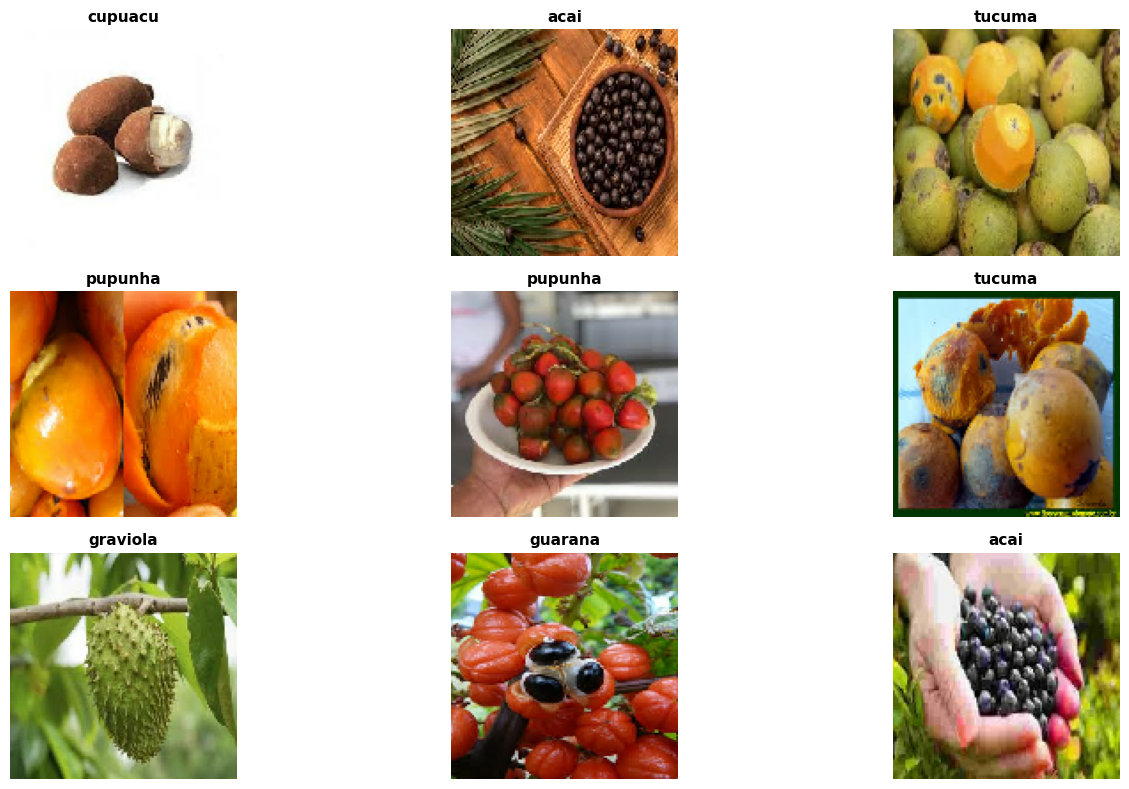


Datasets are ready for model training!


In [15]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# Define image size and batch size
img_height = 128  # Image height
img_width = 128   # Image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# Set the train directory
train_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\train"
test_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\workshop 5\\FruitinAmazon\\test"

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0, 1]

print("Loading training dataset...")
print("-" * 70)

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

print("Training dataset created successfully!")
print(f"Train dataset batches: {len(train_ds)}")
print(f"Batch size: {batch_size}")
print()

print("Loading validation dataset...")
print("-" * 70)

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Validation dataset created successfully!")
print(f"Validation dataset batches: {len(val_ds)}")
print()

print("Loading test dataset...")
print("-" * 70)

# Create test dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("Test dataset created successfully!")
print(f"Test dataset batches: {len(test_ds)}")
print()

# Get class names
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Image size: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")
print("=" * 70)
print()

# Visualize a batch of images from training dataset
print("Visualizing one batch from training dataset...")
print("-" * 70)

plt.figure(figsize=(15, 8))

# Get one batch from training dataset
for images, labels in train_ds.take(1):
    # Display 9 images from the batch
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        
        # Convert normalized image back to [0, 255] for display
        img_display = (images[i].numpy() * 255).astype('uint8')
        plt.imshow(img_display)
        
        label_idx = labels[i].numpy()
        plt.title(f"{class_names[label_idx]}", fontsize=11, fontweight='bold')
        plt.axis('off')

plt.tight_layout()
plt.savefig('training_batch_samples.png', dpi=100, bbox_inches='tight')
print("✓ Batch visualization saved as 'training_batch_samples.png'")
plt.show()

print()
print("=" * 70)
print("Datasets are ready for model training!")
print("=" * 70)

## Task 3 - Implement a CNN with

In [16]:
from tensorflow import keras
from tensorflow.keras import layers, models

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', 
                  strides=1, input_shape=(img_height, img_width, 3)),
    layers.Activation('relu'),
    
    # Max Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    
    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1),
    layers.Activation('relu'),
    
    # Max Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    
    # Flatten Layer
    layers.Flatten(),
    
    # Fully Connected Network
    layers.Dense(64, activation='relu'),      # Hidden Layer 1
    layers.Dense(128, activation='relu'),     # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
])
 
print("Model architecture created successfully!/n")
print("Model Summary:")

model.summary()


Model architecture created successfully!/n
Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
    
• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
 
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.1797 - loss: 1.8757
Epoch 1: val_loss improved from None to 1.44383, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.2083 - loss: 1.9598 - val_accuracy: 0.8333 - val_loss: 1.4438
Epoch 2/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3516 - loss: 1.6487 
Epoch 2: val_loss did not improve from 1.44383
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3194 - loss: 1.6329 - val_accuracy: 0.0556 - val_loss: 1.8619
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6016 - loss: 1.4070 
Epoch 3: val_loss improved from 1.44383 to 1.35609, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5972 - loss: 1.3524 - val_accuracy: 0.4444 - val_loss: 1.3561
Epoch 4/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6797 - loss: 1.0116 
Epoch 4: val_loss improved from 1.35609 to 1.20137, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7083 - loss: 0.9808 - val_accuracy: 0.5556 - val_loss: 1.2014
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6719 - loss: 0.8059 
Epoch 5: val_loss improved from 1.20137 to 0.58168, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7222 - loss: 0.7439 - val_accuracy: 0.8333 - val_loss: 0.5817
Epoch 6/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8750 - loss: 0.4709 
Epoch 6: val_loss did not improve from 0.58168
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8611 - loss: 0.5310 - val_accuracy: 0.8333 - val_loss: 0.6041
Epoch 7/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9609 - loss: 0.3009 
Epoch 7: val_loss did not improve from 0.58168
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9444 - loss: 0.3430 - val_accuracy: 0.8333 - val_loss: 0.7312
Epoch 8/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9531 - loss: 0.2129 
Epoch 8: val_loss improved from 0.58168 to 0.29537, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9583 - loss: 0.2162 - val_accuracy: 0.8889 - val_loss: 0.2954
Epoch 9/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9688 - loss: 0.1653 
Epoch 9: val_loss did not improve from 0.29537
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9722 - loss: 0.1599 - val_accuracy: 0.8333 - val_loss: 0.6685
Epoch 10/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9766 - loss: 0.1064 
Epoch 10: val_loss did not improve from 0.29537
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9722 - loss: 0.1238 - val_accuracy: 0.8333 - val_loss: 0.5339
Epoch 11/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0474 
Epoch 11: val_loss improved from 0.29537 to 0.29490, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 1.0000 - loss: 0.0684 - val_accuracy: 0.8889 - val_loss: 0.2949
Epoch 12/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0328 
Epoch 12: val_loss did not improve from 0.29490
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9861 - loss: 0.0500 - val_accuracy: 0.8333 - val_loss: 0.5835
Epoch 13/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0279 
Epoch 13: val_loss did not improve from 0.29490
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0259 - val_accuracy: 0.8333 - val_loss: 0.3545
Epoch 14/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0139 
Epoch 14: val_loss improved from 0.29490 to 0.28870, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.8889 - val_loss: 0.2887
Epoch 15/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0235 
Epoch 15: val_loss improved from 0.28870 to 0.21498, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 0.8889 - val_loss: 0.2150
Epoch 16/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0090 
Epoch 16: val_loss did not improve from 0.21498
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.8889 - val_loss: 0.2185
Epoch 17/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0051 
Epoch 17: val_loss did not improve from 0.21498
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.8889 - val_loss: 0.2195
Epoch 18/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.0034 
Epoch 18: val_loss did not improve from 0.21498
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.8889 - val_loss: 0.2269
Epoch 19/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0035 
Epoch

##Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [19]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
 
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6667 - loss: 1.1710
Test Loss: 1.1710
Test Accuracy: 0.6667 (66.67%)


## Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [21]:
model.save('trained_fruit_model.h5')
print("Model saved as 'trained_fruit_model.h5'")
 
# Load the saved model
loaded_model = keras.models.load_model('trained_fruit_model.h5')
print("Model loaded successfully!")
 
# Re-evaluate on test set
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds, verbose=0)

Model saved as 'trained_fruit_model.h5'
Model loaded successfully!


## Task 7: Predictions and Classification Report

Making Predictions

• Use model.predict() to make predictions on test images.
    
• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification


In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get all predictions on test set
y_true = []
y_pred = []
 
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)
 
y_true = np.array(y_true)
y_pred = np.array(y_pred)
 
# Print Classification Report
print("CLASSIFICATION REPORT ")

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)
 
# Confusion Matrix
print("Confusion Matrix: ")

cm = confusion_matrix(y_true, y_pred)
print(cm)


CLASSIFICATION REPORT 
              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.80      0.80      0.80         5
     guarana       0.67      0.80      0.73         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.67        30
   macro avg       0.71      0.67      0.65        30
weighted avg       0.71      0.67      0.65        30

Confusion Matrix: 
[[5 0 0 0 0 0]
 [1 3 1 0 0 0]
 [0 0 4 1 0 0]
 [1 0 0 4 0 0]
 [0 0 0 1 2 2]
 [2 1 0 0 0 2]]


The fruit classification model demonstrates MODERATE performance with 67% 
accuracy. The model shows promise, particularly for graviola (80% F1-score) 
and acai (perfect recall), but struggles with tucuma classification.
 
The main challenge is distinguishing between morphologically similar fruits 
(pupunha and tucuma). With more training data, advanced architectures, and 
hyperparameter optimization, the model's performance can be significantly 
improved.